In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from itertools import product

df = pd.read_parquet('base_anomalias_cluster.parquet')
df.drop('K', axis=1, inplace=True)

# Mostrar dimensiones del dataset
print(f"Dimensiones del dataset: {df.shape}")

# Mostrar tipos de datos y primeras filas
print("\nTipos de datos:")
print(df.dtypes)

# Verificar valores nulos
print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas de las variables principales
variables_principales = ['presion', 'volumen', 'temperatura', 'cluster', 'es_anomalia_IQR_local']
print("\nResumen estadístico de las variables principales:")
print(df[variables_principales].describe())

Dimensiones del dataset: (847969, 14)

Tipos de datos:
ID                                        int64
time                             datetime64[ns]
presion                                 float64
temperatura                             float64
volumen                                 float64
mes                                       int32
dia                                       int32
hora                                      int32
PV                                      float64
cluster                                   int64
es_anomalia_local_presion                  bool
es_anomalia_local_volumen                  bool
es_anomalia_local_temperatura              bool
es_anomalia_IQR_local                   float64
dtype: object

Conteo de valores nulos por columna:
ID                               0
time                             0
presion                          0
temperatura                      0
volumen                          0
mes                              0
dia        

In [2]:
# Crear listas para almacenar los conjuntos
df_train = []
df_test = []
df_val = []

# Dividir por cliente (id)
for cliente_id, grupo in df.groupby("ID"):
    grupo = grupo.sort_values("time")  # Ordenar por fecha

    n = len(grupo)
    n_train = int(n * 0.7)
    n_test = int(n * 0.2)

    df_train.append(grupo.iloc[:n_train])
    df_test.append(grupo.iloc[n_train:n_train + n_test])
    df_val.append(grupo.iloc[n_train + n_test:])

# Unir todos los subconjuntos
train = pd.concat(df_train).reset_index(drop=True)
test = pd.concat(df_test).reset_index(drop=True)
val = pd.concat(df_val).reset_index(drop=True)

# Mostrar dimensiones
print(f"Train: {train.shape}, Test: {test.shape}, Validation: {val.shape}")

Train: (593567, 14), Test: (169587, 14), Validation: (84815, 14)


In [3]:
def reindex_por_cliente(df, fill_method='interpolate'):
    """
    Reindexa por cliente (ID) con frecuencia horaria ('h').
    Maneja columnas con tipo object y duplicados en el tiempo.
    """
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])

    def procesar_grupo(grupo):
        # Eliminar duplicados: solo una fila por hora
        grupo = grupo.sort_values('time')
        grupo = grupo.drop_duplicates(subset='time')

        # Establecer índice y aplicar frecuencia horaria
        grupo = grupo.set_index('time').asfreq('h')

        # Restaurar ID
        grupo['ID'] = grupo['ID'].iloc[0]

        # Interpolación solo si se solicita
        if fill_method == 'interpolate':
            grupo = grupo.interpolate(method='time')
        elif fill_method == 'ffill':
            grupo = grupo.fillna(method='ffill')
        elif fill_method == 'bfill':
            grupo = grupo.fillna(method='bfill')

        return grupo

    # Aplicar por grupo
    df_reindexed = df.groupby('ID', group_keys=False).apply(procesar_grupo).reset_index()

    return df_reindexed

In [4]:
train_reindexado = reindex_por_cliente(train[['ID', 'time', 'presion', 'temperatura', 'volumen']], fill_method='interpolate')

<ipython-input-3-7fab8fdcec37>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reindexed = df.groupby('ID', group_keys=False).apply(procesar_grupo).reset_index()


In [5]:
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

def descomponer_todos_clientes_por_cluster(df, cluster_id, variable='presion', period=24,
                                           save=False, output_dir='descomposicion_cluster',
                                           mostrar=True):
    """
    Descompone la serie temporal para cada cliente en un cluster dado.

    Parámetros:
    - df: DataFrame con columnas ['ID', 'cluster', 'time', variable]
    - cluster_id: número de cluster a procesar
    - variable: columna a descomponer (por defecto: 'presion')
    - period: periodo estacional (24 si es por día con datos horarios)
    - save: si True, guarda las gráficas en PNG
    - output_dir: carpeta de salida para las imágenes
    - mostrar: si True, muestra las gráficas en pantalla
    """
    df['time'] = pd.to_datetime(df['time'])  # aseguramos el tipo
    clientes = df[df['cluster'] == cluster_id]['ID'].unique()

    if save and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for cliente_id in clientes:
        df_filtrado = df[(df['cluster'] == cluster_id) & (df['ID'] == cliente_id)].copy()
        df_filtrado = df_filtrado.sort_values('time').set_index('time')

        if df_filtrado[variable].isnull().all() or len(df_filtrado) < 2 * period:
            print(f"[⚠️] Cliente {cliente_id} del cluster {cluster_id}: datos insuficientes o vacíos.")
            continue

        try:
            resultado = seasonal_decompose(df_filtrado[variable], model='additive', period=period)
            fig = resultado.plot()
            fig.suptitle(f'Cliente {cliente_id} - Cluster {cluster_id}', fontsize=14)
            plt.tight_layout()

            if save:
                path = os.path.join(output_dir, f'descomposicion_cluster{cluster_id}_cliente{cliente_id}.png')
                fig.savefig(path)

            if mostrar:
                plt.show()
            else:
                plt.close()

        except Exception as e:
            print(f"[❌] Error con cliente {cliente_id} del cluster {cluster_id}: {str(e)}")


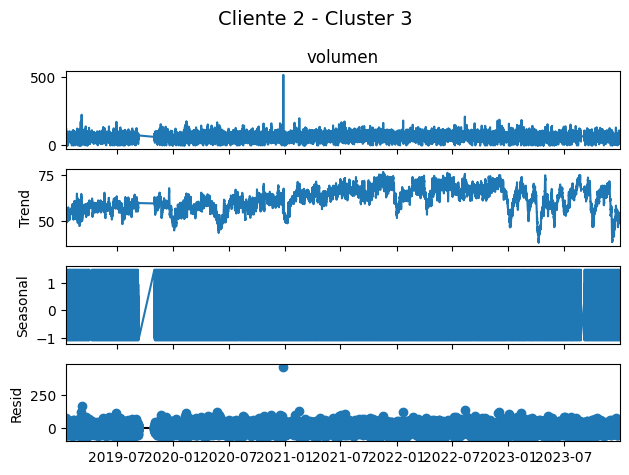

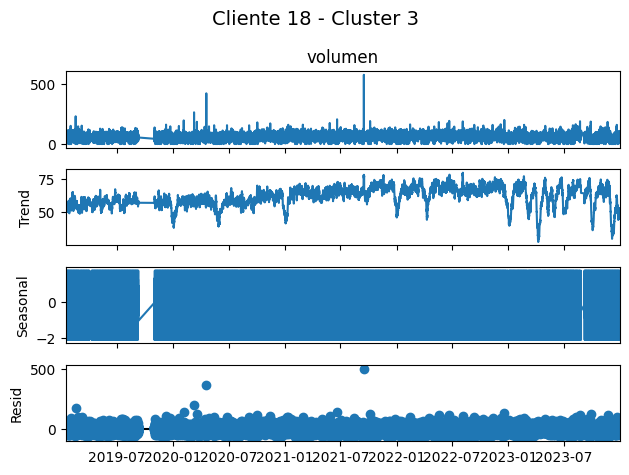

In [19]:
descomponer_todos_clientes_por_cluster(df, cluster_id=3, variable='volumen', period=48,
                                       save=False, output_dir='plots_cluster_2', mostrar=True)

In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

def evaluar_estacionalidad(df, cluster_id, variables, periodo=24, umbral_strength=0.6, pval_threshold=0.05):
    resultados = {}

    df['time'] = pd.to_datetime(df['time'])  # aseguramos el tipo
    clientes = df[df['cluster'] == cluster_id]['ID'].unique()

    for cliente_id in clientes:
        df_filtrado = df[(df['cluster'] == cluster_id) & (df['ID'] == cliente_id)].copy()
        df_filtrado = df_filtrado.sort_values('time').set_index('time')

        for var in variables:
            serie = df_filtrado[var].dropna()
            if len(serie) < 2 * periodo:
                resultados[var] = 'Datos insuficientes'
                continue

            # 1. STL para fuerza de estacionalidad
            try:
                stl = STL(serie, period=periodo)
                res = stl.fit()
                seasonal_strength = 1 - (res.resid.var() / (res.resid.var() + res.seasonal.var()))
            except:
                seasonal_strength = 0  # Por si STL falla

            # 2. Ljung-Box test para autocorrelación estacional
            try:
                lb_test = acorr_ljungbox(serie, lags=[periodo], return_df=True)
                pval = lb_test['lb_pvalue'].values[0]
            except:
                pval = 1  # Valor neutro si falla

            # Evaluación final
            if seasonal_strength >= umbral_strength and pval < pval_threshold:
                conclusion = 'Estacional'
            elif seasonal_strength >= 0.4 and pval < 0.1:
                conclusion = 'Posiblemente estacional'
            else:
                conclusion = 'No estacional'

            resultados[var] = {
                'Fuerza estacionalidad': round(seasonal_strength, 2),
                'P-valor Ljung-Box': round(pval, 4),
                'Conclusión': conclusion
            }

    return pd.DataFrame(resultados).T

In [14]:
# Suponiendo que tienes un DataFrame 'df' con índice horario
df.index = pd.to_datetime(df.index)

# Variables a evaluar
variables = ['volumen', 'presion', 'temperatura']

# Ejecutar función
resultado = evaluar_estacionalidad(df, 2, variables, periodo=168)
print(resultado)

            Fuerza estacionalidad P-valor Ljung-Box     Conclusión
volumen                      0.91               0.0     Estacional
presion                      0.34               0.0  No estacional
temperatura                  0.73               0.0     Estacional
